In [16]:
import pandas as pd
import numpy as np


file_path = '/kaggle/input/datasets/sudheerabhi/heart-csv/heart.csv' 

# Load the data
df = pd.read_csv(file_path)

# Show the first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [17]:
# Check if any cells are empty
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


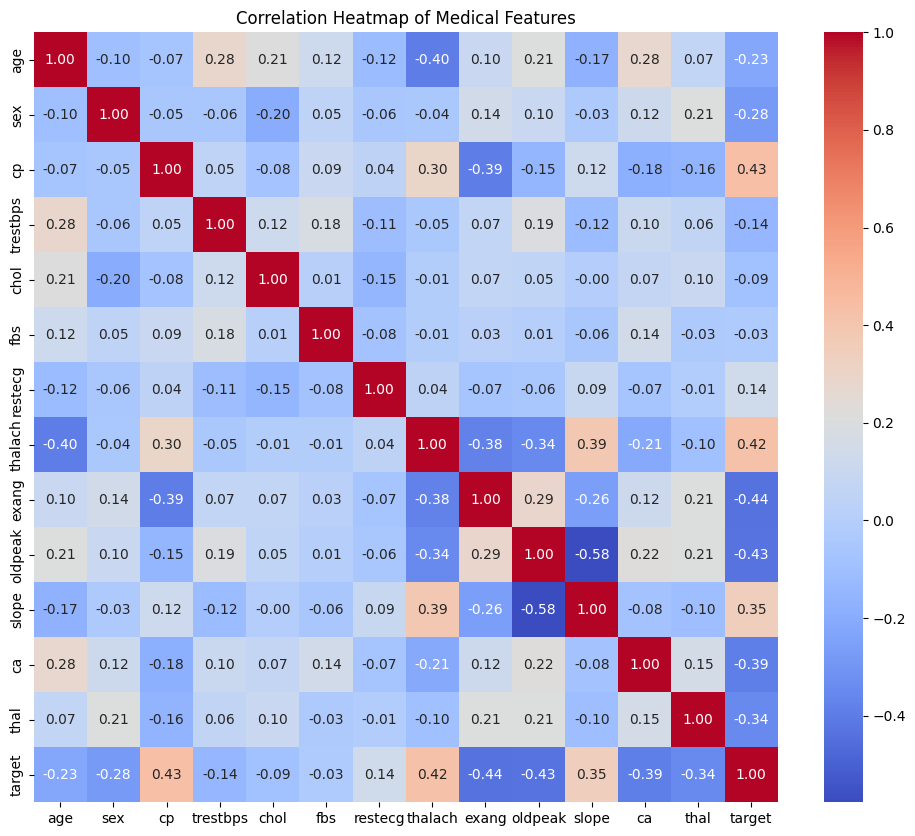

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap to see correlations
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Medical Features")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define X (Symptoms) and y (Diagnosis)
X = df.drop('target', axis=1) 
y = df['target']

# 2. Scale the data (makes it easier for the AI to learn)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split: 80% to train the AI, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data is ready for the AI!")

Data is ready for the AI!


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Ask the AI to predict the test results
predictions = model.predict(X_test)

# See how well it did!
print("--- Model Performance ---")
print(classification_report(y_test, predictions))

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



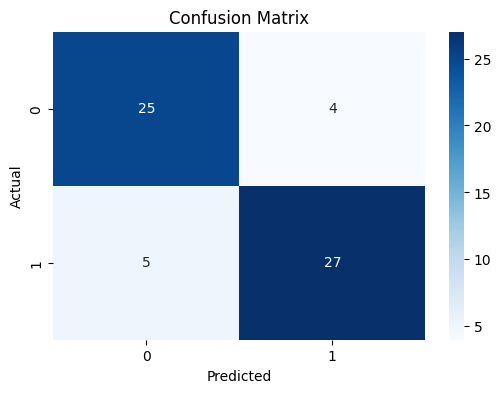

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Build the CNN Architecture (The "Eyes" of the AI)
cnn_model = models.Sequential([
    # First layer: Looking for edges and shapes
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Second layer: Looking for more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Turning the 2D image into a 1D list of features
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary: Normal vs Pneumonia
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("CNN Architecture built successfully!")
cnn_model.summary()

CNN Architecture built successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     5,308,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,327,937 (20.32 MB)

 Trainable params: 5,327,937 (20.32 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Load the pre-trained model (This requires Internet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base
base_model.trainable = False

# 3. Add your medical classification layer
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

print("MobileNetV2 is ready! ✅")

MobileNetV2 is ready! ✅


In [24]:
from transformers import pipeline

# We will use 'text-generation' which is more widely supported
# This uses 'GPT-2', a very famous model for explaining things
generator = pipeline("text-generation", model="gpt2")

print("NLP Explainer is ready! 🗣️")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

NLP Explainer is ready! 🗣️


/tmp/ipykernel_55/2765156280.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=feature_names, palette='magma')


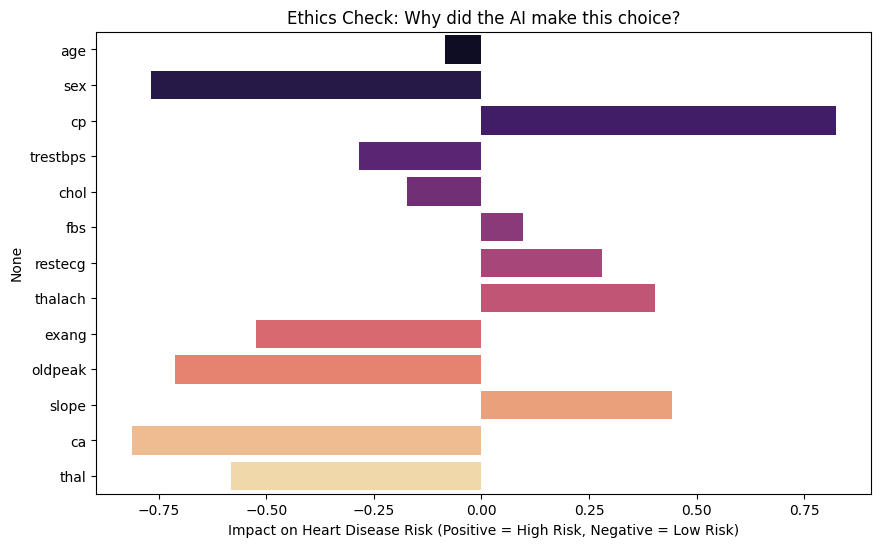

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# We are using the 'weights' (coefficients) from your Logistic Regression model
importance = model.coef_[0]
feature_names = X.columns # age, sex, chol, etc.

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importance, y=feature_names, palette='magma')
plt.title("Ethics Check: Why did the AI make this choice?")
plt.xlabel("Impact on Heart Disease Risk (Positive = High Risk, Negative = Low Risk)")
plt.show()